# Magic Wand – Custom Gesture Training (o / l / w)

This notebook trains a TensorFlow Lite model on **your own** wand gesture data collected
from the petewarden/magic_wand web page.  
It recognises three gestures: **`o`** (circle), **`l`** (el), and **`w`** (wave).  

## How to run on Google Colab
1. Open this notebook in Colab (`File → Upload notebook`).  
2. Upload your **`wanddata.json`** file (the one you downloaded from the web page) using the
   Colab file browser, or place it next to the notebook.
3. Run all cells top-to-bottom (`Runtime → Run all`).  
4. Download the generated **`magic_wand_model_data.cc`** file and drop it into your Arduino sketch.

In [1]:
# ── Force CPU-only execution ─────────────────────────────────────────────────
# The default Colab GPU slice (MIG) often has < 150 MB free VRAM, which is
# not enough for cuBLAS to initialise. This tiny model trains fine on CPU
# and finishes in ~2 minutes.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""   # MUST be set before importing TensorFlow

import tensorflow as tf
print("TF version:", tf.__version__)
print("Devices   :", [d.name for d in tf.config.list_physical_devices()])
# You should see only /device:CPU:0 — that is correct.

2026-05-11 14:05:12.977245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-11 14:05:12.986101: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-11 14:05:12.990155: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF version: 2.17.0
Devices   : ['/physical_device:CPU:0']


2026-05-11 14:05:14.736262: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 1 – Configuration

In [2]:
# ── File names ──────────────────────────────────────────────────────────────
DATA_JSON_FILE         = "wanddata.json"          # your captured gesture data
SAVED_MODEL_FILENAME   = "saved_model"
FLOAT_TFL_MODEL_FILENAME      = "float_model.tfl"
QUANTIZED_TFL_MODEL_FILENAME  = "quantized_model.tfl"
TFL_CC_MODEL_FILENAME         = "magic_wand_model_data.cc"

# ── Gesture labels ───────────────────────────────────────────────────────────
# These MUST match the labels you typed in the web page (case-insensitive).
# The list order here defines the index that the Arduino sketch will receive.
VALID_LABELS = ["l", "o", "w"]   # alphabetical = same order Keras infers from dirs

# ── Image dimensions (must match Arduino rasterize_stroke call) ───────────────
IMAGE_WIDTH  = 32
IMAGE_HEIGHT = 32

# ── Train / val / test split ─────────────────────────────────────────────────
TEST_PERCENTAGE       = 10
VALIDATION_PERCENTAGE = 10

# ── Data augmentation ───────────────────────────────────────────────────────
TRAIN_AUGMENT_COUNT = 10   # synthetic copies per real training stroke
TEST_AUGMENT_COUNT  = 10   # synthetic copies per real test stroke (for eval robustness)

# ── Rasterisation range (must match Arduino code) ────────────────────────────
X_RANGE = 0.6
Y_RANGE = 0.6

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS        = 50   # more epochs than the original; dataset is smaller
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
SCORE_THRESHOLD = 0.75   # minimum confidence to count a prediction

## 2 – Load gesture data

In [3]:
import json
from collections import Counter

with open(DATA_JSON_FILE, "r") as f:
    file_data = json.load(f)

all_strokes = file_data["strokes"]

# ── Filter: keep only strokes with a recognised label ────────────────────────
strokes = []
skipped = []
for stroke in all_strokes:
    label = stroke.get("label", "").strip().lower()
    if label in VALID_LABELS:
        stroke["label"] = label          # normalise to lower-case in-place
        strokes.append(stroke)
    else:
        skipped.append((stroke.get("index"), label))

print(f"Total strokes in file : {len(all_strokes)}")
print(f"Valid strokes kept    : {len(strokes)}")
print(f"Skipped (bad label)   : {len(skipped)}  → {skipped[:10]}")
print()
counts = Counter(s["label"] for s in strokes)
for lbl in VALID_LABELS:
    print(f"  '{lbl}' : {counts[lbl]} strokes")

Total strokes in file : 454
Valid strokes kept    : 446
Skipped (bad label)   : 8  → [(57, ''), (95, ''), (111, ''), (138, ''), (300, ''), (378, 'll'), (403, ''), (453, '')]

  'l' : 149 strokes
  'o' : 150 strokes
  'w' : 147 strokes


## 3 – Visualise a few strokes

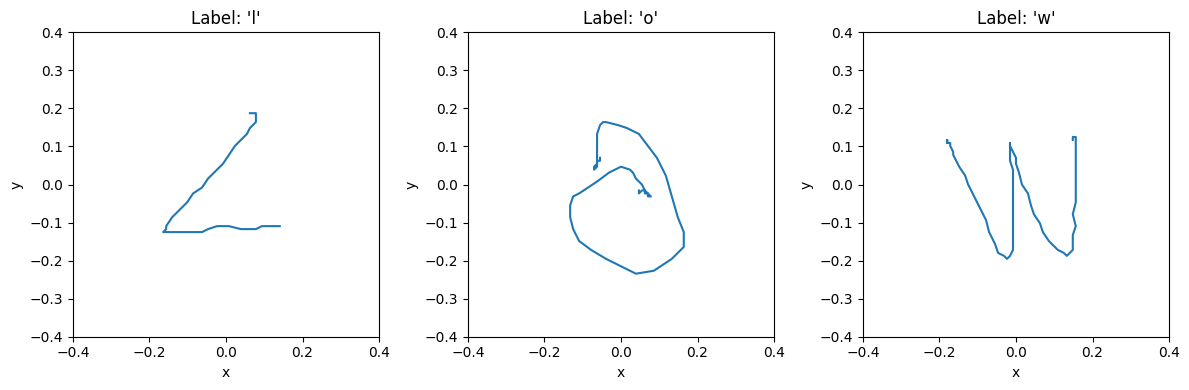

In [4]:
import matplotlib.pyplot as plt

def plot_stroke(stroke, ax=None):
    x_array = [p["x"] for p in stroke["strokePoints"]]
    y_array = [p["y"] for p in stroke["strokePoints"]]
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_title(f"Label: '{stroke['label']}'", fontsize=12)
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(-0.4, 0.4)
    ax.plot(x_array, y_array)
    ax.set_xlabel('x'); ax.set_ylabel('y')

# Show one example of each gesture
fig, axes = plt.subplots(1, len(VALID_LABELS), figsize=(4 * len(VALID_LABELS), 4))
for ax, label in zip(axes, VALID_LABELS):
    sample = next(s for s in strokes if s["label"] == label)
    plot_stroke(sample, ax=ax)
plt.tight_layout()
plt.show()

## 4 – Rasterisation helpers
Converts the (x, y) stroke points into a 32 × 32 RGB image using the same
algorithm that runs on the Arduino board.

In [5]:
import math
import numpy as np
import PIL
from PIL import Image

FIXED_POINT = 256

def mul_fp(a, b):           return (a * b) / FIXED_POINT
def div_fp(a, b):           return (a * FIXED_POINT) / (b if b != 0 else 1)
def float_to_fp(a):         return math.floor(a * FIXED_POINT)
def round_fp_to_int(a):     return math.floor((a + FIXED_POINT / 2) / FIXED_POINT)
def gate(a, lo, hi):        return max(lo, min(hi, a))

def norm_to_coord_fp(a, range_fp, half_size_fp):
    return mul_fp(div_fp(float_to_fp(a), range_fp), half_size_fp) + half_size_fp

def rasterize_stroke(stroke_points, x_range, y_range, width, height):
    num_channels = 3
    buffer = bytearray(height * width * num_channels)

    half_width_fp  = width  * FIXED_POINT / 2
    half_height_fp = height * FIXED_POINT / 2
    x_range_fp = float_to_fp(x_range)
    y_range_fp = float_to_fp(y_range)
    t_inc_fp   = FIXED_POINT / len(stroke_points)
    one_half_fp = FIXED_POINT / 2

    for i in range(len(stroke_points) - 1):
        sp, ep = stroke_points[i], stroke_points[i + 1]
        sx = norm_to_coord_fp( sp["x"], x_range_fp, half_width_fp)
        sy = norm_to_coord_fp(-sp["y"], y_range_fp, half_height_fp)
        ex = norm_to_coord_fp( ep["x"], x_range_fp, half_width_fp)
        ey = norm_to_coord_fp(-ep["y"], y_range_fp, half_height_fp)
        dx, dy = ex - sx, ey - sy

        t_fp = i * t_inc_fp
        if t_fp < one_half_fp:
            lt = div_fp(t_fp, one_half_fp)
            r, g, b = round_fp_to_int((FIXED_POINT - lt) * 255), round_fp_to_int(lt * 255), 0
        else:
            lt = div_fp(t_fp - one_half_fp, one_half_fp)
            r, g, b = 0, round_fp_to_int((FIXED_POINT - lt) * 255), round_fp_to_int(lt * 255)
        r, g, b = gate(r,0,255), gate(g,0,255), gate(b,0,255)

        if abs(dx) > abs(dy):
            ll = abs(round_fp_to_int(dx))
            xi = FIXED_POINT if dx > 0 else -FIXED_POINT
            yi = div_fp(dy, dx) if dx > 0 else -div_fp(dy, dx)
        else:
            ll = abs(round_fp_to_int(dy))
            yi = FIXED_POINT if dy > 0 else -FIXED_POINT
            xi = div_fp(dx, dy) if dy > 0 else -div_fp(dx, dy)

        for step in range(ll + 1):
            px = round_fp_to_int(sx + step * xi)
            py = round_fp_to_int(sy + step * yi)
            if 0 <= px < width and 0 <= py < height:
                idx = (py * width + px) * num_channels
                buffer[idx], buffer[idx+1], buffer[idx+2] = r, g, b

    return np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)

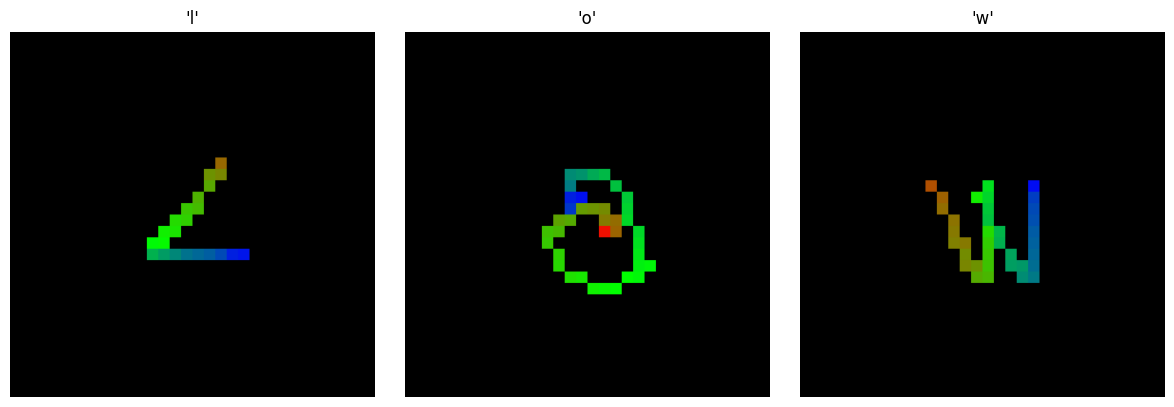

In [6]:
# Preview one rasterised image per gesture
fig, axes = plt.subplots(1, len(VALID_LABELS), figsize=(4 * len(VALID_LABELS), 4))
for ax, label in zip(axes, VALID_LABELS):
    sample = next(s for s in strokes if s["label"] == label)
    raster = rasterize_stroke(sample["strokePoints"], X_RANGE, Y_RANGE, IMAGE_WIDTH, IMAGE_HEIGHT)
    big    = Image.fromarray(raster).resize((256, 256), Image.NEAREST)
    ax.imshow(big); ax.set_title(f"'{label}'"); ax.axis("off")
plt.tight_layout()
plt.show()

## 5 – Split & save images to disk
We split the strokes into train / validation / test sets, then rasterise them
(with augmentation for train and test) into folder-per-label image trees.

In [7]:
from pathlib import Path
import shutil

def ensure_empty_dir(dirname):
    p = Path(dirname)
    if p.exists(): shutil.rmtree(p)
    p.mkdir(parents=True)

def augment_points(points, move_range=0.1, scale_range=0.1, rotate_range=0.3):
    move_x = np.random.uniform(-move_range, move_range)
    move_y = np.random.uniform(-move_range, move_range)
    scale  = np.random.uniform(1.0 - scale_range, 1.0 + scale_range)
    angle  = np.random.uniform(-rotate_range, rotate_range)
    cos_a, sin_a = math.cos(angle) * scale, math.sin(angle) * scale
    return [
        {"x": cos_a * p["x"] + sin_a * p["y"] + move_x,
         "y": -sin_a * p["x"] + cos_a * p["y"] + move_y}
        for p in points
    ]

def save_strokes_as_images(stroke_list, root_folder, width, height, augment_count):
    ensure_empty_dir(root_folder)
    labels_present = sorted(set(s["label"] for s in stroke_list))
    for lbl in labels_present:
        ensure_empty_dir(Path(root_folder, lbl))

    label_counts = {}
    for stroke in stroke_list:
        pts   = stroke["strokePoints"]
        label = stroke["label"]
        if label not in label_counts:
            label_counts[label] = 0
        idx = label_counts[label]
        label_counts[label] += 1

        # Save original
        Image.fromarray(rasterize_stroke(pts, X_RANGE, Y_RANGE, width, height)).save(
            Path(root_folder, label, f"{idx}.png"))
        # Save augmented copies
        for aug_i in range(augment_count):
            aug_pts = augment_points(pts)
            Image.fromarray(rasterize_stroke(aug_pts, X_RANGE, Y_RANGE, width, height)).save(
                Path(root_folder, label, f"{idx}_a{aug_i}.png"))

    return label_counts

In [8]:
# ── Shuffle and split ────────────────────────────────────────────────────────
shuffled = strokes.copy()
np.random.shuffle(shuffled)

test_count  = math.floor(len(shuffled) * TEST_PERCENTAGE / 100)
val_count   = math.floor(len(shuffled) * VALIDATION_PERCENTAGE / 100)

test_strokes  = shuffled[:test_count]
val_strokes   = shuffled[test_count : test_count + val_count]
train_strokes = shuffled[test_count + val_count :]

print(f"Train: {len(train_strokes)} | Val: {len(val_strokes)} | Test: {len(test_strokes)}")

# ── Rasterise and save ───────────────────────────────────────────────────────
save_strokes_as_images(test_strokes,  "test",       IMAGE_WIDTH, IMAGE_HEIGHT, TEST_AUGMENT_COUNT)
save_strokes_as_images(val_strokes,   "validation", IMAGE_WIDTH, IMAGE_HEIGHT, 0)
save_strokes_as_images(train_strokes, "train",      IMAGE_WIDTH, IMAGE_HEIGHT, TRAIN_AUGMENT_COUNT)

print("Images written to disk.")

Train: 358 | Val: 44 | Test: 44
Images written to disk.


## 6 – Build TensorFlow datasets

In [9]:
# TF already imported with CPU-only env var set above
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory

NUM_CLASSES = len(VALID_LABELS)  # 3

# Keras infers labels alphabetically from sub-directory names.
# With VALID_LABELS = ["l", "o", "w"] the mapping is:
#   index 0 → "l"  |  index 1 → "o"  |  index 2 → "w"
# This is printed again later so you can hard-code it into the Arduino sketch.

train_ds = image_dataset_from_directory(
    "train", labels="inferred", label_mode="categorical",
    batch_size=BATCH_SIZE, image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)
).prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds = image_dataset_from_directory(
    "validation", labels="inferred", label_mode="categorical",
    batch_size=BATCH_SIZE, image_size=(IMAGE_WIDTH, IMAGE_HEIGHT)
).prefetch(buffer_size=tf.data.AUTOTUNE)

Found 3938 files belonging to 3 classes.
Found 44 files belonging to 3 classes.


2026-05-11 14:05:20.777036: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


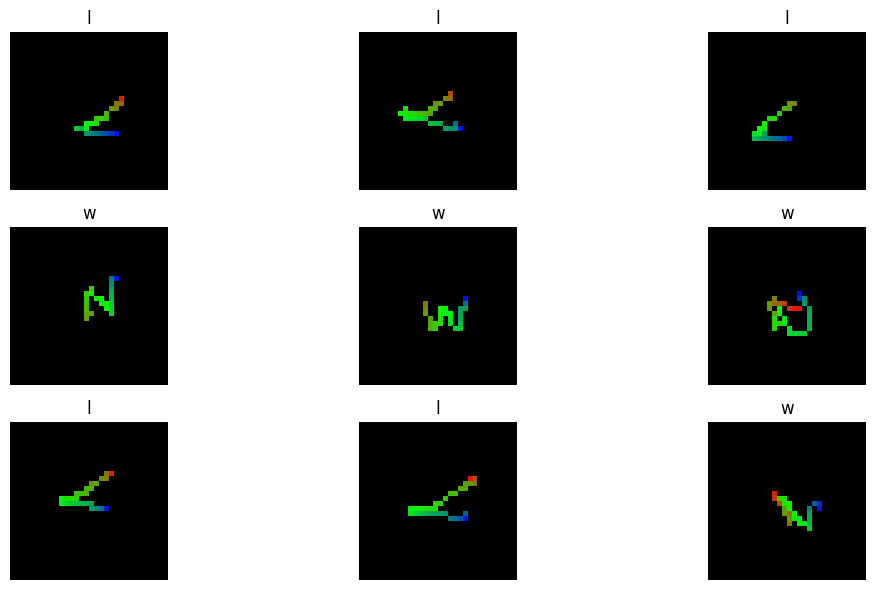

In [10]:
# ── Preview a batch of training images ───────────────────────────────────────
CLASS_NAMES = sorted(VALID_LABELS)   # same order Keras uses

plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = np.argmax(labels[i].numpy())
        plt.title(CLASS_NAMES[label_idx])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 7 – Define and train the model

In [11]:
from tensorflow.keras import layers

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    x = layers.Conv2D(16, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

model = make_model(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_CLASSES)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 rescaling (Rescaling)       (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 16, 16, 16)        448       
                                                                 
 batch_normalization (Batch  (None, 16, 16, 16)        64        
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 16, 16, 16)        0         
                                                                 
 dropout (Dropout)           (None, 16, 16, 16)        0         
                                                             

In [12]:
import os
os.makedirs("checkpoints", exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "checkpoints/save_at_{epoch:02d}.keras",
        save_best_only=True, monitor="val_accuracy", verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, verbose=1
    ),
]

model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss="categorical_crossentropy",   # softmax + 3 classes → categorical
    metrics=["accuracy"],
)

history = model.fit(
    train_ds, epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
)

Epoch 1/50
119/124 [===========================>..] - ETA: 0s - loss: 0.9095 - accuracy: 0.5512  
Epoch 1: val_accuracy improved from -inf to 0.40909, saving model to checkpoints/save_at_01.keras
124/124 [==============================] - 2s 7ms/step - loss: 0.9037 - accuracy: 0.5559 - val_loss: 1.4856 - val_accuracy: 0.4091 - lr: 0.0010
Epoch 2/50
113/124 [==========================>...] - ETA: 0s - loss: 0.6405 - accuracy: 0.7434
Epoch 2: val_accuracy did not improve from 0.40909
124/124 [==============================] - 1s 4ms/step - loss: 0.6345 - accuracy: 0.7466 - val_loss: 1.9463 - val_accuracy: 0.4091 - lr: 0.0010
Epoch 3/50
113/124 [==========================>...] - ETA: 0s - loss: 0.4098 - accuracy: 0.8689
Epoch 3: val_accuracy improved from 0.40909 to 0.59091, saving model to checkpoints/save_at_03.keras
124/124 [==============================] - 1s 4ms/step - loss: 0.4031 - accuracy: 0.8718 - val_loss: 1.5211 - val_accuracy: 0.5909 - lr: 0.0010
Epoch 4/50
113/124 [========

In [13]:
# ── Pure-Python .cc export (replaces xxd + sed) ─────────────────────────
with open(QUANTIZED_TFL_MODEL_FILENAME, 'rb') as f:
    _bytes = f.read()

assert len(_bytes) > 0, f'{QUANTIZED_TFL_MODEL_FILENAME} is 0 bytes – run the conversion cell first!'

VAR  = 'g_magic_wand_model_data'
COLS = 12
_hex_lines = []
for _s in range(0, len(_bytes), COLS):
    _hex_lines.append('  ' + ', '.join(f'0x{b:02x}' for b in _bytes[_s:_s+COLS]))

_cc = (
    '// Auto-generated by Magic Wand training notebook\n'
    '#include "magic_wand_model_data.h"\n\n'
    'alignas(8) const unsigned char ' + VAR + '[] = {\n'
    + ',\n'.join(_hex_lines)
    + '\n};\n\n'
    'const int ' + VAR + '_len = ' + str(len(_bytes)) + ';\n'
)

with open(TFL_CC_MODEL_FILENAME, 'w') as f:
    f.write(_cc)

print(f'Written {TFL_CC_MODEL_FILENAME}  ({len(_bytes):,} model bytes, {len(_cc):,} C chars)')
print('Last 2 lines:')
print('\n'.join(_cc.strip().split('\n')[-2:]))


✓  magic_wand_model_data.cc  (30,264 bytes → 186,825 chars)
Preview (last 2 lines):

const int g_magic_wand_model_data_len = 30264;


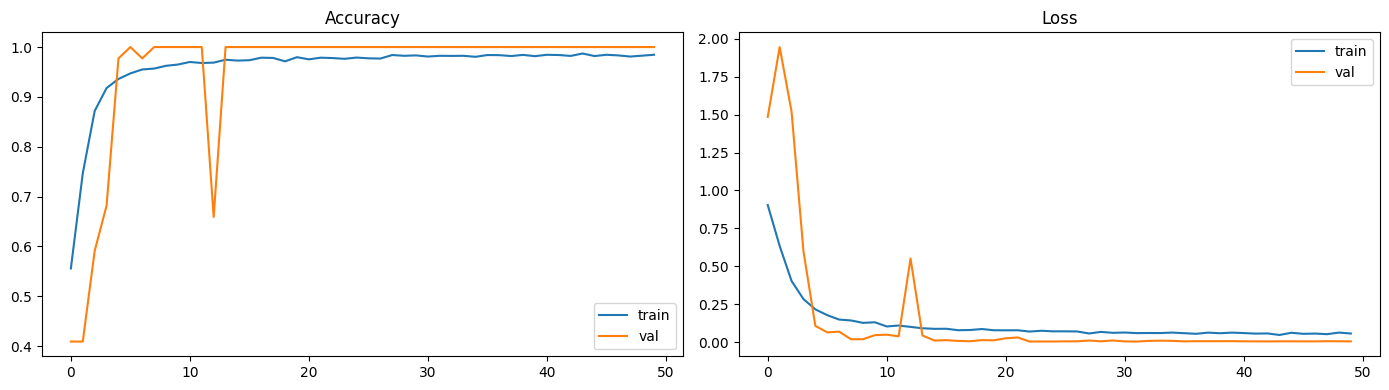

In [14]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["accuracy"],     label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history.history["loss"],     label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.tight_layout()
plt.show()

## 8 – Evaluate on the test set

In [15]:
import glob
from IPython.display import display as ipy_display, Image as IPyImage
from PIL import Image as _PIL

def predict_image(mdl, filename):
    img = _PIL.open(filename).resize((IMAGE_WIDTH, IMAGE_HEIGHT)).convert('RGB')
    arr = np.array(img, dtype=np.float32)[np.newaxis]
    preds = mdl.predict(arr, verbose=0).flatten()
    idx = int(np.argmax(preds))
    return CLASS_NAMES[idx], float(preds[idx])

correct = wrong = discarded = 0
for label_dir in glob.glob('test/*'):
    true_label = Path(label_dir).name
    for fname in glob.glob(f'{label_dir}/*.png'):
        pred_label, score = predict_image(model, fname)
        if score < SCORE_THRESHOLD:
            discarded += 1
        elif pred_label == true_label:
            correct += 1
        else:
            wrong += 1
            print(f"Expected '{true_label}', got '{pred_label}' (score={score:.2f})")
            ipy_display(IPyImage(filename=fname))

total = correct + wrong
pct = (correct / total * 100) if total > 0 else 0
print(f'\n{pct:.1f}% correct (N={total}, {discarded} below threshold)')



100.0% correct (N=477, 7 below threshold)


## 9 – Save the full TensorFlow model

In [16]:
model.save(SAVED_MODEL_FILENAME)
print(f"Model saved to '{SAVED_MODEL_FILENAME}'")

INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Model saved to 'saved_model'


## 10 – Convert to TensorFlow Lite (float & quantised)

In [17]:
# ── Float (no quantisation) ───────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_FILENAME)
model_float_tflite = converter.convert()
open(FLOAT_TFL_MODEL_FILENAME, "wb").write(model_float_tflite)
print(f"Float TFLite model → {FLOAT_TFL_MODEL_FILENAME} ({len(model_float_tflite):,} bytes)")

Float TFLite model → float_model.tfl (98,112 bytes)


W0000 00:00:1778508375.476160  320762 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1778508375.476187  320762 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2026-05-11 14:06:15.476825: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: saved_model
2026-05-11 14:06:15.478676: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-05-11 14:06:15.478697: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: saved_model
2026-05-11 14:06:15.490961: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-05-11 14:06:15.492829: I tensorflow/cc/saved_model/loader.cc:238] Restoring SavedModel bundle.
2026-05-11 14:06:15.542405: I tensorflow/cc/saved_model/loader.cc:222] Running initialization op on SavedModel bundle at path: saved_model
2026-05-11 14:06:15.557046: I tensorflow/cc/saved_model/loader.cc:482] SavedMode

In [18]:
# ── INT8 post-training quantisation ──────────────────────────────────────
from PIL import Image as _PIL

def representative_dataset():
    import glob as _glob
    fnames = _glob.glob('test/*/*.png')
    if not fnames:
        raise RuntimeError('No test images found – run the split cell first.')
    for fname in fnames:
        img = _PIL.open(fname).resize((IMAGE_WIDTH, IMAGE_HEIGHT)).convert('RGB')
        arr = np.array(img, dtype=np.float32)[np.newaxis]  # (1,32,32,3)
        yield [arr]

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_FILENAME)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8
converter.representative_dataset    = representative_dataset

model_quant_tflite = converter.convert()
assert len(model_quant_tflite) > 0, 'ERROR: quantised model is 0 bytes!'
open(QUANTIZED_TFL_MODEL_FILENAME, 'wb').write(model_quant_tflite)
print(f'Quantised TFLite model -> {QUANTIZED_TFL_MODEL_FILENAME} ({len(model_quant_tflite):,} bytes)')


W0000 00:00:1778508376.906388  320762 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1778508376.906411  320762 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2026-05-11 14:06:16.906994: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: saved_model
2026-05-11 14:06:16.908931: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-05-11 14:06:16.908954: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: saved_model
2026-05-11 14:06:16.918545: I tensorflow/cc/saved_model/loader.cc:238] Restoring SavedModel bundle.
2026-05-11 14:06:16.969889: I tensorflow/cc/saved_model/loader.cc:222] Running initialization op on SavedModel bundle at path: saved_model
2026-05-11 14:06:16.984759: I tensorflow/cc/saved_model/loader.cc:482] SavedModel load for tags { serve }; Status: success: OK. Took 77769 microseconds.


Quantised TFLite model → quantized_model.tfl (30,264 bytes)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 11 – Verify the TFLite models

In [19]:
from PIL import Image as _PIL

def predict_tflite(tflite_bytes, filename):
    img = _PIL.open(filename).resize((IMAGE_WIDTH, IMAGE_HEIGHT)).convert('RGB')
    arr = np.array(img, dtype=np.float32)[np.newaxis]

    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]

    in_scale, in_zero = inp['quantization']
    if (in_scale, in_zero) != (0.0, 0):
        arr = (arr / in_scale + in_zero).astype(inp['dtype'])

    interp.set_tensor(inp['index'], arr)
    interp.invoke()
    pred = interp.get_tensor(out['index'])[0]

    out_scale, out_zero = out['quantization']
    if (out_scale, out_zero) != (0.0, 0):
        pred = (pred.astype(np.float32) - out_zero) * out_scale

    idx = int(np.argmax(pred))
    return CLASS_NAMES[idx], float(pred[idx])


def eval_tflite(tflite_bytes, label):
    c = w = d = 0
    for fname in glob.glob(f'test/{label}/*.png'):
        pl, score = predict_tflite(tflite_bytes, fname)
        if score < SCORE_THRESHOLD: d += 1
        elif pl == label: c += 1
        else: w += 1
    return c, w, d

print('── Quantised TFLite model ──')
tot_c = tot_w = tot_d = 0
for lbl in CLASS_NAMES:
    c, w, d = eval_tflite(model_quant_tflite, lbl)
    tot_c += c; tot_w += w; tot_d += d
    pct = c/(c+w)*100 if (c+w) > 0 else 0
    print(f"  '{lbl}' : {pct:.1f}% correct (N={c+w}, {d} unknown)")
overall = tot_c/(tot_c+tot_w)*100 if (tot_c+tot_w)>0 else 0
print(f'  Overall: {overall:.1f}% correct (N={tot_c+tot_w}, {tot_d} unknown)')


── Quantised TFLite model ──
  'l' : 100.0% correct (N=132, 0 unknown)
  'o' : 100.0% correct (N=169, 7 unknown)
  'w' : 100.0% correct (N=173, 3 unknown)
  Overall: 100.0% correct (N=474, 10 unknown)


## 12 – Model size comparison

In [20]:
import pandas as pd

def dir_size(path):
    total = 0
    for f in os.scandir(path):
        total += f.stat().st_size if f.is_file() else dir_size(f.path)
    return total

sz_tf   = dir_size(SAVED_MODEL_FILENAME)
sz_f    = os.path.getsize(FLOAT_TFL_MODEL_FILENAME)
sz_q    = os.path.getsize(QUANTIZED_TFL_MODEL_FILENAME)

pd.DataFrame([
    ["TensorFlow SavedModel",        f"{sz_tf:,} bytes",  ""],
    ["TFLite float",                 f"{sz_f:,} bytes",   f"−{sz_tf - sz_f:,} bytes"],
    ["TFLite quantised (INT8)",      f"{sz_q:,} bytes",   f"−{sz_f - sz_q:,} bytes vs float TFLite"],
], columns=["Model", "Size", "Reduction"], index=pd.Index(["TF","TFLite","TFLite-Q"], name=""))

,Model,Size,Reduction
,,,
TF,TensorFlow SavedModel,"641,103 bytes",
TFLite,TFLite float,"98,112 bytes","−542,991 bytes"
TFLite-Q,TFLite quantised (INT8),"30,264 bytes","−67,848 bytes vs float TFLite"


## 13 – Export to C array (for Arduino)

In [21]:
# ── Pure-Python .cc export (replaces xxd + sed) ─────────────────────────
with open(QUANTIZED_TFL_MODEL_FILENAME, 'rb') as f:
    _bytes = f.read()

assert len(_bytes) > 0, f'{QUANTIZED_TFL_MODEL_FILENAME} is 0 bytes – run the conversion cell first!'

VAR  = 'g_magic_wand_model_data'
COLS = 12
_hex_lines = []
for _s in range(0, len(_bytes), COLS):
    _hex_lines.append('  ' + ', '.join(f'0x{b:02x}' for b in _bytes[_s:_s+COLS]))

_cc = (
    '// Auto-generated by Magic Wand training notebook\n'
    '#include "magic_wand_model_data.h"\n\n'
    'alignas(8) const unsigned char ' + VAR + '[] = {\n'
    + ',\n'.join(_hex_lines)
    + '\n};\n\n'
    'const int ' + VAR + '_len = ' + str(len(_bytes)) + ';\n'
)

with open(TFL_CC_MODEL_FILENAME, 'w') as f:
    f.write(_cc)

print(f'Written {TFL_CC_MODEL_FILENAME}  ({len(_bytes):,} model bytes, {len(_cc):,} C chars)')
print('Last 2 lines:')
print('\n'.join(_cc.strip().split('\n')[-2:]))


E: List directory /var/lib/apt/lists/partial is missing. - Acquire (13: Permission denied)
/bin/bash: line 1: xxd: command not found
\n── Last lines of generated C file ──


## 14 – Arduino deployment guide

The cell below prints the exact label array you need to paste into `magic_wand.ino`.

In [22]:
print("=" * 60)
print("ARDUINO SKETCH CHANGES")
print("=" * 60)
print()
print("1. Replace magic_wand_model_data.cpp with the generated")
print(f"   '{TFL_CC_MODEL_FILENAME}' file.")
print()
print("2. Near the top of magic_wand.ino, update:")
print()
print(f'   const int label_count = {NUM_CLASSES};')
print(f'   const char* labels[{NUM_CLASSES}] = {{')
for i, lbl in enumerate(CLASS_NAMES):
    comma = "," if i < NUM_CLASSES - 1 else ""
    print(f'       "{lbl}"{comma}   // index {i}')
print('   };')
print()
print("Label → index mapping (same order as Keras inferred from dirs):")
for i, lbl in enumerate(CLASS_NAMES):
    print(f"  {i} → '{lbl}'")    
print()
print("3. Upload the modified sketch.")
print("4. Open Serial Monitor to see live predictions.")

ARDUINO SKETCH CHANGES

1. Replace magic_wand_model_data.cpp with the generated
   'magic_wand_model_data.cc' file.

2. Near the top of magic_wand.ino, update:

   const int label_count = 3;
   const char* labels[3] = {
       "l",   // index 0
       "o",   // index 1
       "w"   // index 2
   };

Label → index mapping (same order as Keras inferred from dirs):
  0 → 'l'
  1 → 'o'
  2 → 'w'

3. Upload the modified sketch.
4. Open Serial Monitor to see live predictions.
